### 今天要回答的問題

> **海表溫距平值越高，就代表海洋熱浪的分級越高嗎？**


本練習將使用 ODB Marine Heatwave API，取得單一地點的月尺度資料，並利用 Python：

1. 呼叫 API 並將 JSON 整理成 DataFrame  
2. API 輸出欄位 (SST、SST anomaly 與 MHW level)  
3. 畫出 距平值 與 海洋熱浪分級 時序圖  
4. 比較 距平值 與 海洋熱浪分級 的關係  

資料來源

- ODB MHW API 文件：  
  https://eco.odb.ntu.edu.tw/api/swagger/mhw
- ODB Marine Heatwaves 網頁：  
  https://eco.odb.ntu.edu.tw/pub/MHW/

熱浪等級對照表

| level | Marine Heatwave category |
|---:|---|
| 0 | Non-MHW |
| 1 | Moderate |
| 2 | Strong |
| 3 | Severe |
| 4 | Extreme |

### 1. 載入套件

這次會使用：

- `requests`：向 API 發送請求
- `pandas`：整理與分析資料
- `matplotlib`：繪製時序圖

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

### 2. 設定查詢條件

先分析臺灣東北方、黑潮流經附近的一個格點：

- 經度：122.625°E
- 緯度：25.375°N
- 時間：2010-01 至 2025-12

ODB MHW API 的單點查詢沒有時間長度限制。

> 日期仍建議填寫每月第一天，例如 `2015-01-01`。

In [2]:
# API endpoint
url = "https://eco.odb.ntu.edu.tw/api/mhw"

# 位置與時間
lon = 122.625
lat = 25.375
start_date = "2010-01-01"
end_date = "2025-12-01"

# append 希望 API 回傳的欄位
params = {
    "lon0": lon,
    "lat0": lat,
    "start": start_date,
    "end": end_date,
    "append": "sst,sst_anomaly,level",
}

params

{'lon0': 122.625,
 'lat0': 25.375,
 'start': '2010-01-01',
 'end': '2025-12-01',
 'append': 'sst,sst_anomaly,level'}

### 3. 呼叫 API

`requests.get()` 會把查詢條件送到 ODB API。

`raise_for_status()` 可在 API 回傳錯誤狀態時立即顯示錯誤，而不是繼續處理不完整的資料。

In [3]:
response = requests.get(url, params=params, timeout=60)
response.raise_for_status()

print("Request URL:")
print(response.url)
print()
print("HTTP status:", response.status_code)

Request URL:
https://eco.odb.ntu.edu.tw/api/mhw?lon0=122.625&lat0=25.375&start=2010-01-01&end=2025-12-01&append=sst%2Csst_anomaly%2Clevel

HTTP status: 200


### 4. 將 JSON 整理成 DataFrame

API 通常會回傳由多筆紀錄組成的 JSON。

下方程式可以滿足：
- JSON 最外層直接是 list
- JSON 最外層是 dictionary，資料放在其中某個 list 欄位

In [4]:
json_data = response.json()

if isinstance(json_data, list):
    records = json_data
elif isinstance(json_data, dict):
    # 嘗試尋找 dictionary 中第一個由多筆紀錄組成的 list
    list_values = [value for value in json_data.values() if isinstance(value, list)]
    if not list_values:
        raise ValueError(
            "API 回傳的是 dictionary，但沒有找到可轉成表格的 list。"
            f"\n回傳欄位：{list(json_data.keys())}"
        )
    records = list_values[0]
else:
    raise TypeError(f"無法辨識 API 回傳格式：{type(json_data)}")

df = pd.json_normalize(records)

print("資料筆數：", len(df))
print("欄位：", df.columns.tolist())
df.head()


資料筆數： 192
欄位： ['lon', 'lat', 'date', 'level', 'sst', 'sst_anomaly']


,lon,lat,date,level,sst,sst_anomaly
0,122.625,25.375,2010-01-01,0,22.745161,0.2221
1,122.625,25.375,2010-02-01,0,23.207499,0.7892
2,122.625,25.375,2010-03-01,0,23.853548,0.9971
3,122.625,25.375,2010-04-01,0,24.403332,0.3251
4,122.625,25.375,2010-05-01,0,26.095806,0.4629


### 5. 資料處理流程1｜認識資料

在畫圖以前，請先看看：

1. 這份資料共有幾筆？
2. 有哪些欄位？
3. 最早與最晚的日期分別是什麼時候？
4. 資料是否以一個月為間隔？

In [6]:
# API 輸出欄位通常使用 date；此段 time 欄位也ok
date_candidates = ["date", "time"]
date_col = next((col for col in date_candidates if col in df.columns), None)

if date_col is None:
    raise KeyError(
        "找不到日期欄位。請檢查 df.columns，確認 API 實際使用的欄位名稱。"
    )

df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col).reset_index(drop=True)

print(f"資料筆數：{len(df)}")
print(f"時間範圍：{df[date_col].min().date()} 至 {df[date_col].max().date()}")
print()

df.info()

資料筆數：192
時間範圍：2010-01-01 至 2025-12-01

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   lon          192 non-null    float64       
 1   lat          192 non-null    float64       
 2   date         192 non-null    datetime64[ns]
 3   level        192 non-null    int64         
 4   sst          192 non-null    float64       
 5   sst_anomaly  192 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 9.1 KB


### 5. 資料處理流程2｜檢查缺值與資料型態

分析前先確認重要欄位是否存在，並將數值欄位轉成 numeric。

(這裡只是，以防萬一，若你用別人家的 api)

In [7]:
required_columns = ["sst", "sst_anomaly", "level"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise KeyError(
        f"缺少必要欄位：{missing_columns}\n"
        f"目前欄位：{df.columns.tolist()}"
    )

for col in required_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("各欄位缺值數：")
display(df[[date_col, *required_columns]].isna().sum().to_frame("missing_count"))

df[[date_col, *required_columns]].head()

各欄位缺值數：


,missing_count
date,0
sst,0
sst_anomaly,0
level,0


,date,sst,sst_anomaly,level
0,2010-01-01,22.745161,0.2221,0
1,2010-02-01,23.207499,0.7892,0
2,2010-03-01,23.853548,0.9971,0
3,2010-04-01,24.403332,0.3251,0
4,2010-05-01,26.095806,0.4629,0


### 6. 畫出 SST anomaly 時序

先觀察每個月相對於 1982–2011 氣候平均值

圖中的水平虛線表示 `anomaly = 0`。

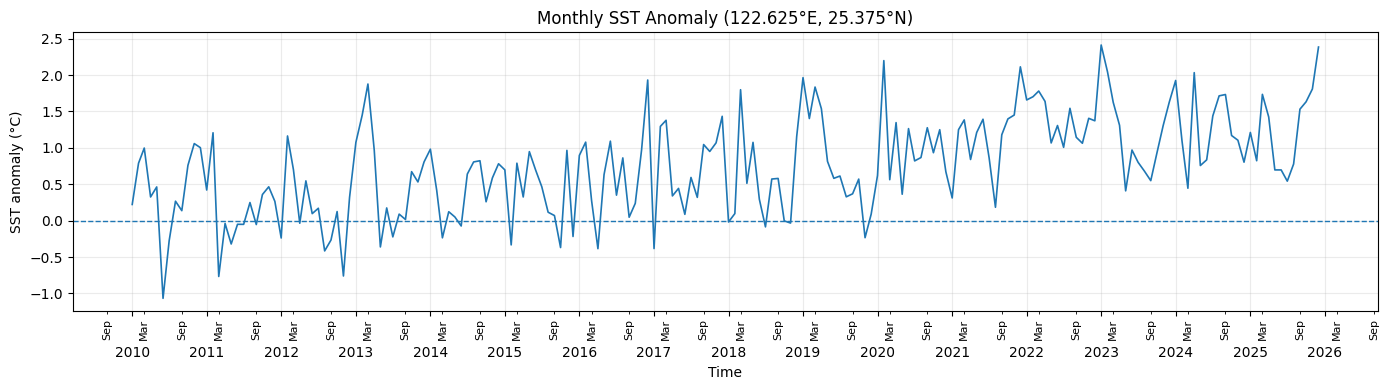

In [12]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df[date_col], df["sst_anomaly"], linewidth=1.2)
ax.axhline(0, linestyle="--", linewidth=1)
# ===== x 軸設定 =====
# 每年一個主刻度
ax.xaxis.set_major_locator(mdates.YearLocator())

# 每六個月一個次刻度
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=6))

# 主刻度顯示年份
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 次刻度顯示月份
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))

# 旋轉月份避免重疊
ax.tick_params(axis='x', which='major', pad=22)
ax.tick_params(axis='x', which='minor', labelsize=8, rotation=90)

ax.set_title(f"Monthly SST Anomaly ({lon}°E, {lat}°N)")
ax.set_xlabel("Time")
ax.set_ylabel("SST anomaly (°C)")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 思考

1. 有沒有哪一個年份或月份的 anomaly 特別高？
2. 是否有一段時間 anomaly 連續多月為正？

### 7. 畫出 Marine Heatwave level

`level` 是海洋熱浪分級，今天選擇用長條圖來做比較。

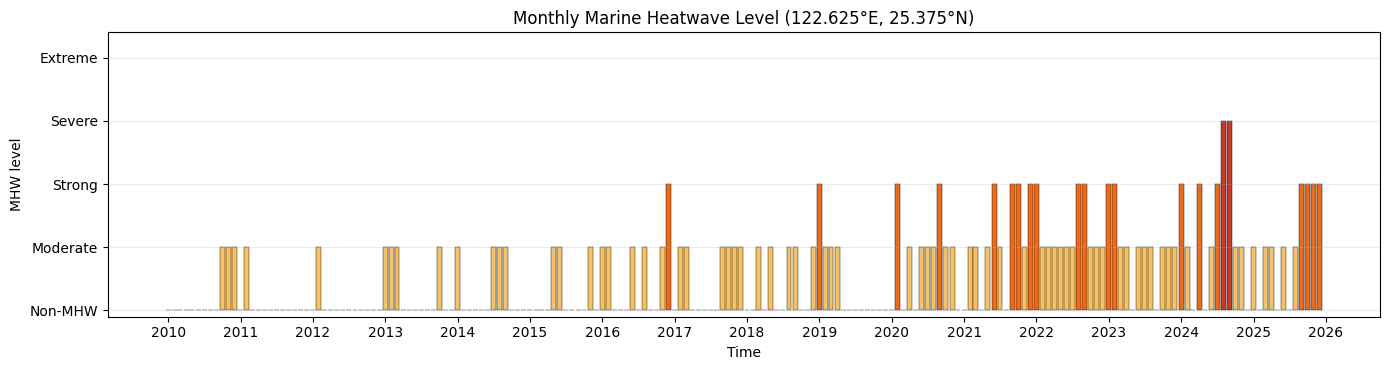

In [16]:
import matplotlib.dates as mdates

level_colors = {
    0: "#f2f2f2",   # Non-MHW
    1: "#f5c268",   # Moderate
    2: "#ec6b1a",   # Strong
    3: "#cb3827",   # Severe
    4: "#7f1416",   # Extreme
}

fig, ax = plt.subplots(figsize=(14, 3.8))

colors = [level_colors.get(int(v), "#cccccc") for v in df["level"]]

ax.bar(
    df[date_col],
    df["level"],
    width=25,
    color=colors,
    edgecolor="black",
    linewidth=0.3,
)

# x 軸
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_title(f"Monthly Marine Heatwave Level ({lon}°E, {lat}°N)")
ax.set_xlabel("Time")
ax.set_ylabel("MHW level")

ax.set_yticks(
    [0, 1, 2, 3, 4],
    ["Non-MHW", "Moderate", "Strong", "Severe", "Extreme"],
)

ax.set_ylim(-0.1, 4.4)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### 8. 將 SST anomaly 與 MHW level 放在同一張圖比較

灰色折線與圓點的位置表示每個月的 SST anomaly。

圓點顏色表示該月份的 Marine Heatwave level：

- 白色：Non-MHW
- 黃色：Moderate
- 橘色：Strong
- 紅色：Severe
- 深紅色：Extreme

請觀察：

1. anomaly 為正的月份，是否一定被判定為 MHW？
2. anomaly 最大的月份，是否一定具有最高的 category？
3. 相近的 anomaly，是否可能對應不同的 category？


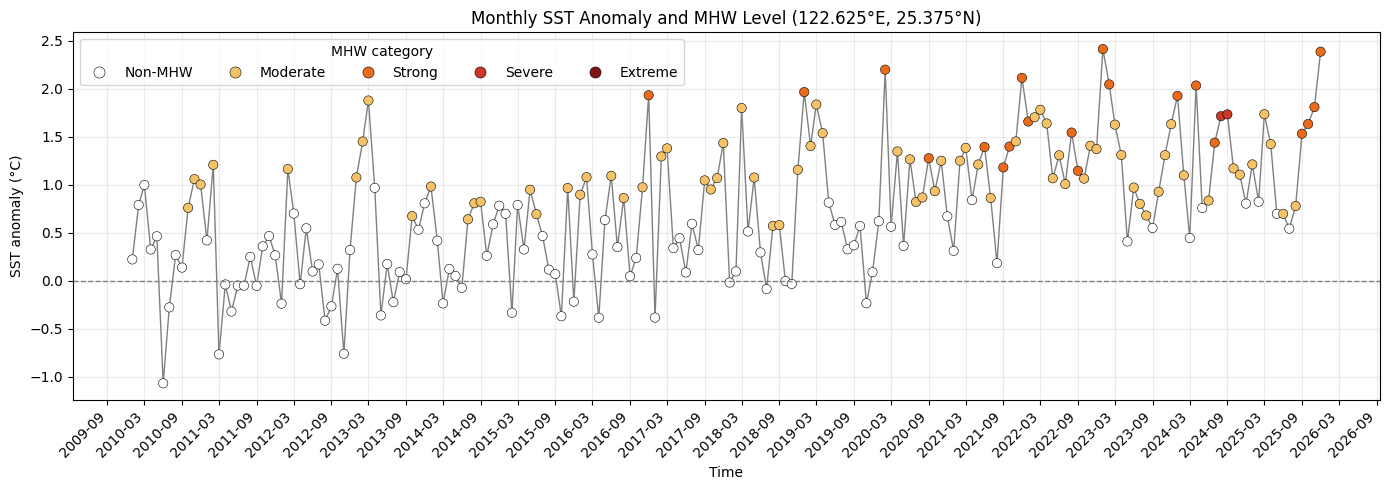

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

level_colors = {
    0: "#ffffff",   # Non-MHW
    1: "#f5c268",   # Moderate
    2: "#ec6b1a",   # Strong
    3: "#cb3827",   # Severe
    4: "#7f1416",   # Extreme
}

level_names = {
    0: "Non-MHW",
    1: "Moderate",
    2: "Strong",
    3: "Severe",
    4: "Extreme",
}

# 根據每筆資料的 level 指定圓點顏色
point_colors = df["level"].map(level_colors)

fig, ax = plt.subplots(figsize=(14, 5))

# SST anomaly 折線
ax.plot(
    df[date_col],
    df["sst_anomaly"],
    linewidth=1,
    color="gray",
    zorder=1,
)

# 每個月份加上圓點，顏色代表 MHW level
ax.scatter(
    df[date_col],
    df["sst_anomaly"],
    c=point_colors,
    s=45,
    edgecolors="black",
    linewidths=0.4,
    zorder=2,
)

# anomaly = 0 參考線
ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    color="gray",
)

# x 軸每 6 個月顯示一次
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title(
    f"Monthly SST Anomaly and MHW Level ({lon}°E, {lat}°N)"
)
ax.set_xlabel("Time")
ax.set_ylabel("SST anomaly (°C)")
ax.grid(alpha=0.25)

# 自訂圖例
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=level_colors[level],
        markeredgecolor="black",
        markeredgewidth=0.4,
        markersize=8,
        label=level_names[level],
    )
    for level in range(5)
]

ax.legend(
    handles=legend_handles,
    title="MHW category",
    loc="upper left",
    ncol=5,
)

plt.tight_layout()
plt.show()

### 挑戰｜用程式回答問題

請不要只靠目測，利用 DataFrame 找出：

1. anomaly 最大的月份  
2. level 最高的月份  
3. 兩者是否為同一個月份  
4. 是否存在 anomaly > 0 但 level = 0 的月份

In [19]:
# anomaly 最大的月份
max_anomaly_row = df.loc[df["sst_anomaly"].idxmax()]

print("Anomaly 最大的月份")
display(
    max_anomaly_row[
        [date_col, "sst", "sst_anomaly", "level"]
    ].to_frame("value")
)

Anomaly 最大的月份


,value
date,2023-01-01 00:00:00
sst,24.935484
sst_anomaly,2.4124
level,2


In [20]:
# level 最高的所有月份
max_level = df["level"].max()

highest_level_months = df.loc[
    df["level"] == max_level,
    [date_col, "sst", "sst_anomaly", "level"],
]

print("資料中的最高 level：", int(max_level))
print("達到最高 level 的月份數：", len(highest_level_months))
display(highest_level_months)


資料中的最高 level： 3
達到最高 level 的月份數： 2


,date,sst,sst_anomaly,level
175,2024-08-01,29.853550,1.7139,3
176,2024-09-01,29.145666,1.7322,3


In [21]:
# 比較 anomaly 最大月份與最高 level
max_anomaly_date = max_anomaly_row[date_col]
max_anomaly_level = max_anomaly_row["level"]

same_as_highest_level = max_anomaly_level == max_level

print("Anomaly 最大月份：", max_anomaly_date.date())
print("該月份的 level：", int(max_anomaly_level))
print("整段資料的最高 level：", int(max_level))
print()
print("Anomaly 最大的月份是否達到最高 level？", same_as_highest_level)


Anomaly 最大月份： 2023-01-01
該月份的 level： 2
整段資料的最高 level： 3

Anomaly 最大的月份是否達到最高 level？ False


In [22]:
# 找出 anomaly 為正，但沒有被判定為 MHW 的月份
positive_but_not_mhw = df.loc[
    (df["sst_anomaly"] > 0) & (df["level"] == 0),
    [date_col, "sst", "sst_anomaly", "level"],
].copy()

print("Anomaly > 0，但 level = 0 的月份數：", len(positive_but_not_mhw))
display(positive_but_not_mhw.head(20))


Anomaly > 0，但 level = 0 的月份數： 71


,date,sst,sst_anomaly,level
0,2010-01-01,22.745161,0.2221,0
1,2010-02-01,23.207499,0.7892,0
2,2010-03-01,23.853548,0.9971,0
3,2010-04-01,24.403332,0.3251,0
4,2010-05-01,26.095806,0.4629,0
7,2010-08-01,28.406775,0.2671,0
8,2010-09-01,27.550333,0.1369,0
12,2011-01-01,22.943548,0.4205,0
19,2011-08-01,28.388386,0.2487,0
21,2011-10-01,26.752256,0.3585,0
